In [1]:
import geopandas as gpd
import pandas as pd

In [2]:
buildings = gpd.read_parquet('output/buildings_rovaniemi.parquet')
depot = gpd.read_file('output/depot_rovaniemi.gpkg')
charging_stations = gpd.read_file('output/ev_stations_rovaniemi.gpkg')           

In [3]:
volume = pd.read_csv('output/volume_demand.csv')

In [4]:
import osmnx as ox
import networkx as nx
import numpy as np
from sklearn.neighbors import BallTree

# Step 1: Build BallTree from depot + charging stations
facility_coords = np.radians(
    # np.array([[depot['latitude'].values[0], depot['longitude'].values[0]]])
    # add charging stations here when you have more:
    np.vstack([depot[['latitude','longitude']].values, 
               charging_stations[['latitude','longitude']].values])
)

building_coords_rad = np.radians(buildings[['latitude', 'longitude']].values)

tree = BallTree(facility_coords, metric='haversine')
distances, indices = tree.query(building_coords_rad, k=1)

# Assign each building to nearest facility
buildings['facility_index'] = indices.flatten()
buildings['distance_to_facility_km'] = distances.flatten() * 6371  # earth radius

# print(buildings.groupby('facility_index').size())
# print(buildings['distance_to_facility_km'].describe())

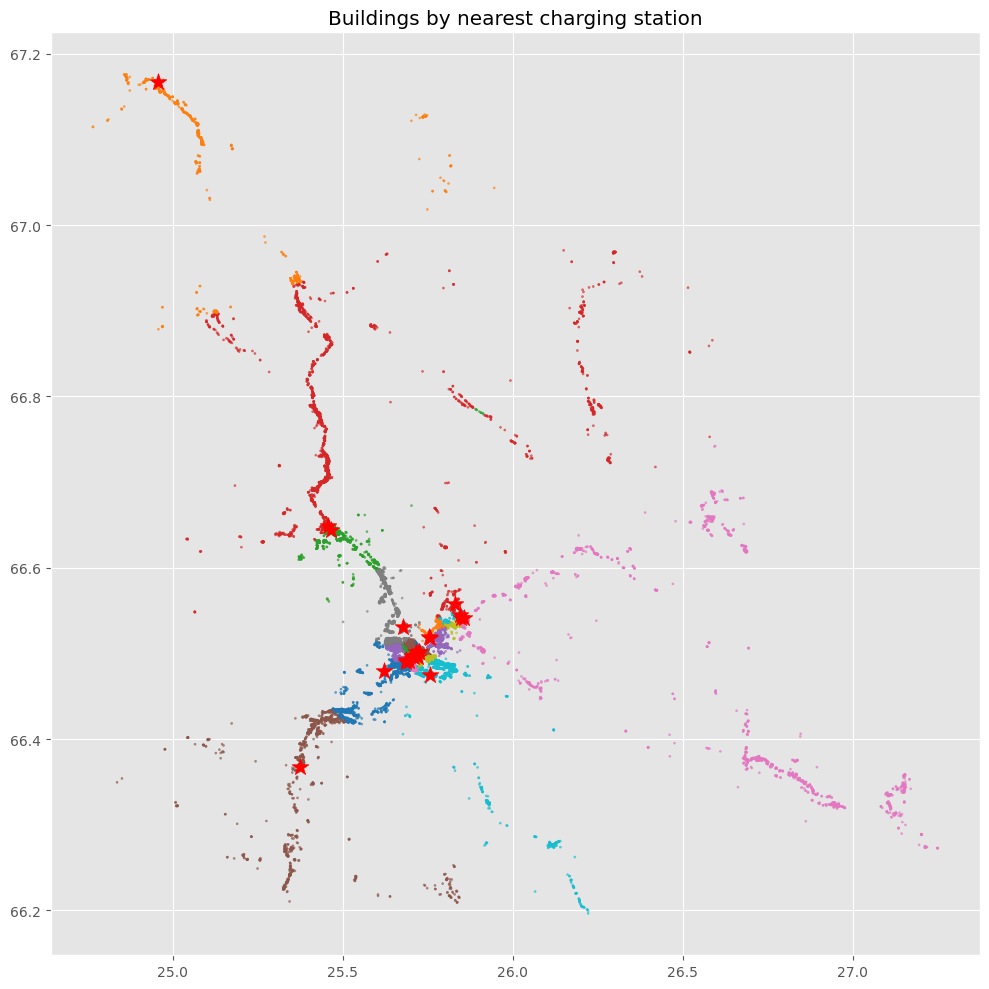

In [5]:
import matplotlib.pyplot as plt

plt.style.use('ggplot')

fig, ax = plt.subplots(figsize=(10, 10))

# Plot buildings colored by nearest facility
scatter = ax.scatter(
    buildings['longitude'],
    buildings['latitude'],
    c=buildings['facility_index'],
    cmap='tab10',
    s=2,
    alpha=0.6,
    label='Buildings'
)

# Plot depot/charging stations
ax.scatter(
    depot['longitude'],
    depot['latitude'],
    c='red',
    s=160,
    zorder=5,
    marker='*',
    label='Depot'
)

ax.scatter(
    charging_stations['longitude'],
    charging_stations['latitude'],
    c='red',
    s=160,
    zorder=5,
    marker='*',
    label='Charging station'
)

# plt.colorbar(scatter, ax=ax, label='Nearest facility index')
ax.set_title('Buildings by nearest charging station')
# ax.legend()
plt.tight_layout()
plt.show()

In [6]:
print(f"Depot: {len(depot)} location(s)")
print(f"Charging stations: {len(charging_stations)} location(s)")
print(charging_stations[['longitude', 'latitude']])

Depot: 1 location(s)
Charging stations: 22 location(s)
    longitude   latitude
0   25.722570  66.501980
1   25.686167  66.489892
2   24.956095  67.167261
3   25.754472  66.518917
4   25.702718  66.496449
5   25.466046  66.644117
6   25.455338  66.649252
7   25.828467  66.557914
8   25.757004  66.517640
9   25.685238  66.492290
10  25.723153  66.501853
11  25.713935  66.501297
12  25.373389  66.367917
13  25.694393  66.490980
14  25.856884  66.540898
15  25.717081  66.498188
16  25.676124  66.530732
17  25.722146  66.496324
18  25.847946  66.541788
19  25.755162  66.474509
20  25.844255  66.544719
21  25.710311  66.495467


In [7]:
print(buildings['distance_to_facility_km'].describe())
print(f"\nBuildings over 30 km from nearest charger: {(buildings['distance_to_facility_km'] > 30).sum()}")
print(f"Buildings over 60 km from nearest charger: {(buildings['distance_to_facility_km'] > 60).sum()}")

count    18045.000000
mean         7.632683
std         12.331669
min          0.012591
25%          1.081882
50%          2.123523
75%          7.357436
max         68.768876
Name: distance_to_facility_km, dtype: float64

Buildings over 30 km from nearest charger: 1531
Buildings over 60 km from nearest charger: 173


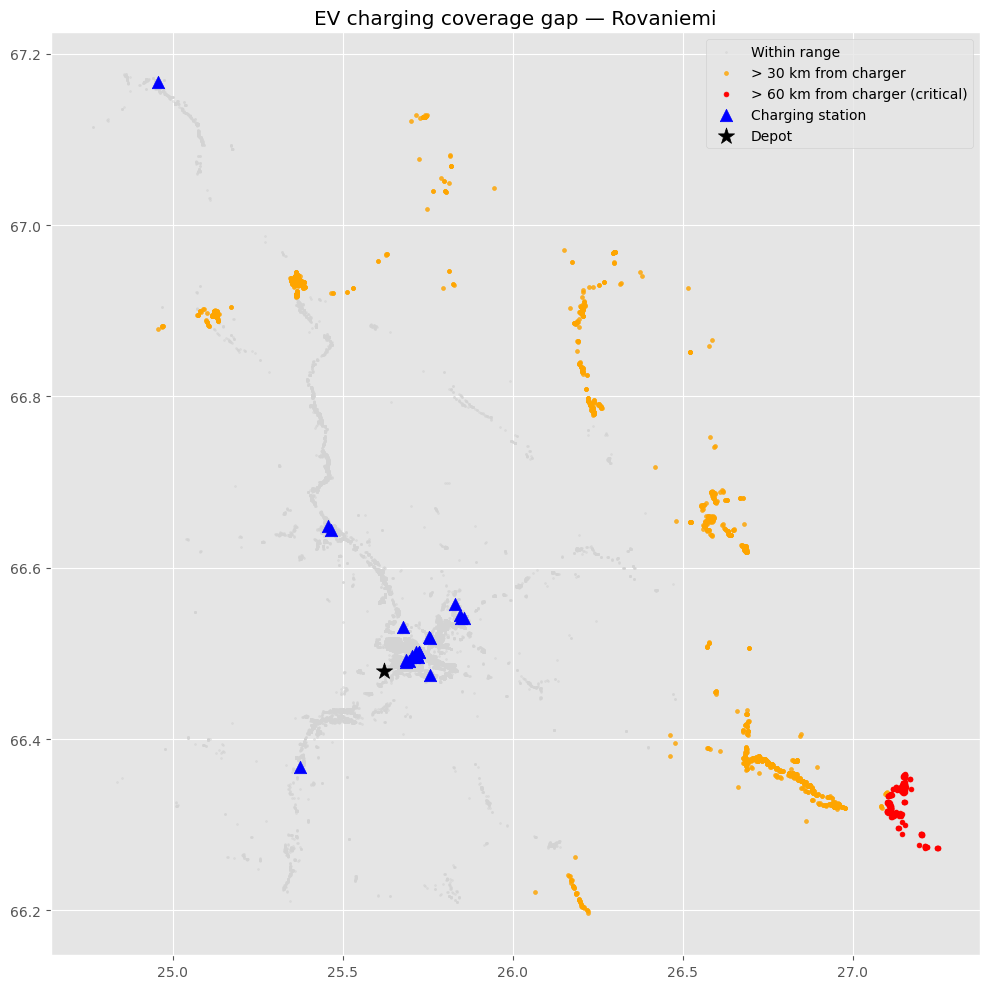

In [8]:
fig, ax = plt.subplots(figsize=(10, 10))

# All buildings in gray
ax.scatter(
    buildings['longitude'],
    buildings['latitude'],
    c='lightgray', s=2, alpha=0.5, label='Within range'
)

# Buildings over 30 km
ax.scatter(
    buildings[buildings['distance_to_facility_km'] > 30]['longitude'],
    buildings[buildings['distance_to_facility_km'] > 30]['latitude'],
    c='orange', s=8, alpha=0.8, label='> 30 km from charger'
)

# Buildings over 60 km
ax.scatter(
    buildings[buildings['distance_to_facility_km'] > 60]['longitude'],
    buildings[buildings['distance_to_facility_km'] > 60]['latitude'],
    c='red', s=12, alpha=1, label='> 60 km from charger (critical)'
)

# Charging stations
ax.scatter(
    charging_stations['longitude'],
    charging_stations['latitude'],
    c='blue', s=80, zorder=5, marker='^', label='Charging station'
)

# Depot
ax.scatter(
    depot['longitude'].values[0],
    depot['latitude'].values[0],
    c='black', s=150, zorder=6, marker='*', label='Depot'
)

ax.set_title('EV charging coverage gap — Rovaniemi')
ax.legend()
plt.tight_layout()
plt.show()

In [9]:
rovaniemi = gpd.read_file('output/rovaniemi_kunta.geojson')

rovaniemi_wgs = rovaniemi.to_crs('4326')
geom = rovaniemi_wgs.at[0, 'geometry']

In [10]:
# geom

In [11]:
import osmnx as ox
import networkx as nx

# Get road network for Rovaniemi
G = ox.graph_from_polygon(geom, network_type ='drive')

# Snap depot to nearest node
depot_node = ox.nearest_nodes(G, depot['longitude'].values[0], depot['latitude'].values[0])

# Snap charging stations to nearest nodes
charging_nodes = ox.nearest_nodes(
    G,
    charging_stations['longitude'].values,
    charging_stations['latitude'].values
)

# Snap buildings to nearest nodes
building_nodes = ox.nearest_nodes(
    G,
    buildings['longitude'].values,
    buildings['latitude'].values
)

buildings['osm_node'] = building_nodes

print(f"Depot node: {depot_node}")
print(f"Charging nodes: {len(charging_nodes)}")
print(f"Building nodes snapped: {len(building_nodes)}")

Depot node: 3246515871
Charging nodes: 22
Building nodes snapped: 18045


In [12]:
def make_linestring(coords):
    unique_coords = list(dict.fromkeys(coords))  # remove duplicates
    if len(unique_coords) > 1:
        return LineString(unique_coords)
    return None

In [13]:
from shapely.geometry import LineString
import geopandas as gpd

VEHICLE_RANGE = 120000  # meters
NUM_VEHICLES = 5

# Divide buildings evenly among vehicles
buildings['vehicle_id'] = buildings.index % NUM_VEHICLES

routes = []  # will store route segments as linestrings

for vehicle_id in range(NUM_VEHICLES):
    vehicle_buildings = buildings[buildings['vehicle_id'] == vehicle_id].copy()
    
    print(f"\nVehicle {vehicle_id}: {len(vehicle_buildings)} buildings")
    
    current_node = depot_node
    remaining_range = VEHICLE_RANGE
    cumulative_distance = 0
    segment_coords = []
    segment_index = 0
    
    for idx, building in vehicle_buildings.iterrows():
        target_node = building['osm_node']
        
        # Distance from current position to next building
        try:
            dist_to_building = nx.shortest_path_length(G, current_node, target_node, weight='length')
        except nx.NetworkXNoPath:
            continue
        
        # Find nearest charging station
        min_charge_dist = float('inf')
        nearest_charge_node = None
        for cn in charging_nodes:
            try:
                d = nx.shortest_path_length(G, current_node, cn, weight='length')
                if d < min_charge_dist:
                    min_charge_dist = d
                    nearest_charge_node = cn
            except nx.NetworkXNoPath:
                continue
        
        # Check if we need to charge before going to next building
        if dist_to_building > remaining_range or (remaining_range - dist_to_building) < min_charge_dist:
            # Save current segment
            if len(segment_coords) > 1:
                routes.append({
                    'vehicle_id': vehicle_id,
                    'segment': segment_index,
                    'type': 'delivery',
                    'distance_m': VEHICLE_RANGE - remaining_range,
                    'geometry': make_linestring(segment_coords)
                })
            
            # Route to nearest charging station
            try:
                charge_path = nx.shortest_path(G, current_node, nearest_charge_node, weight='length')
                charge_coords = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in charge_path]
                routes.append({
                    'vehicle_id': vehicle_id,
                    'segment': segment_index,
                    'type': 'charging',
                    'distance_m': min_charge_dist,
                    'geometry': make_linestring(charge_coords)
                })
            except nx.NetworkXNoPath:
                pass
            
            # Reset range and start new segment
            current_node = nearest_charge_node
            remaining_range = VEHICLE_RANGE
            segment_index += 1
            segment_coords = [(G.nodes[nearest_charge_node]['x'], G.nodes[nearest_charge_node]['y'])]
        
        # Route to building
        try:
            path = nx.shortest_path(G, current_node, target_node, weight='length')
            path_coords = [(G.nodes[n]['x'], G.nodes[n]['y']) for n in path]
            segment_coords.extend(path_coords)
            remaining_range -= dist_to_building
            cumulative_distance += dist_to_building
            current_node = target_node
        except nx.NetworkXNoPath:
            continue
    
    # Save last segment
    if len(segment_coords) > 1:
        routes.append({
            'vehicle_id': vehicle_id,
            'segment': segment_index,
            'type': 'delivery',
            'distance_m': VEHICLE_RANGE - remaining_range,
            'geometry': make_linestring(segment_coords)
        })

# Convert to GeoDataFrame
routes_gdf = gpd.GeoDataFrame(routes, crs="EPSG:4326")
print(f"\nTotal route segments: {len(routes_gdf)}")
print(routes_gdf.groupby(['vehicle_id', 'type']).size().reset_index(name='segments'))


Vehicle 0: 3609 buildings

Vehicle 1: 3609 buildings

Vehicle 2: 3609 buildings

Vehicle 3: 3609 buildings

Vehicle 4: 3609 buildings

Total route segments: 1539
   vehicle_id      type  segments
0           0  delivery         1
1           1  charging       188
2           1  delivery       189
3           2  charging       197
4           2  delivery       198
5           3  charging       192
6           3  delivery       193
7           4  charging       190
8           4  delivery       191


Saved to rovaniemi_routes.gpkg


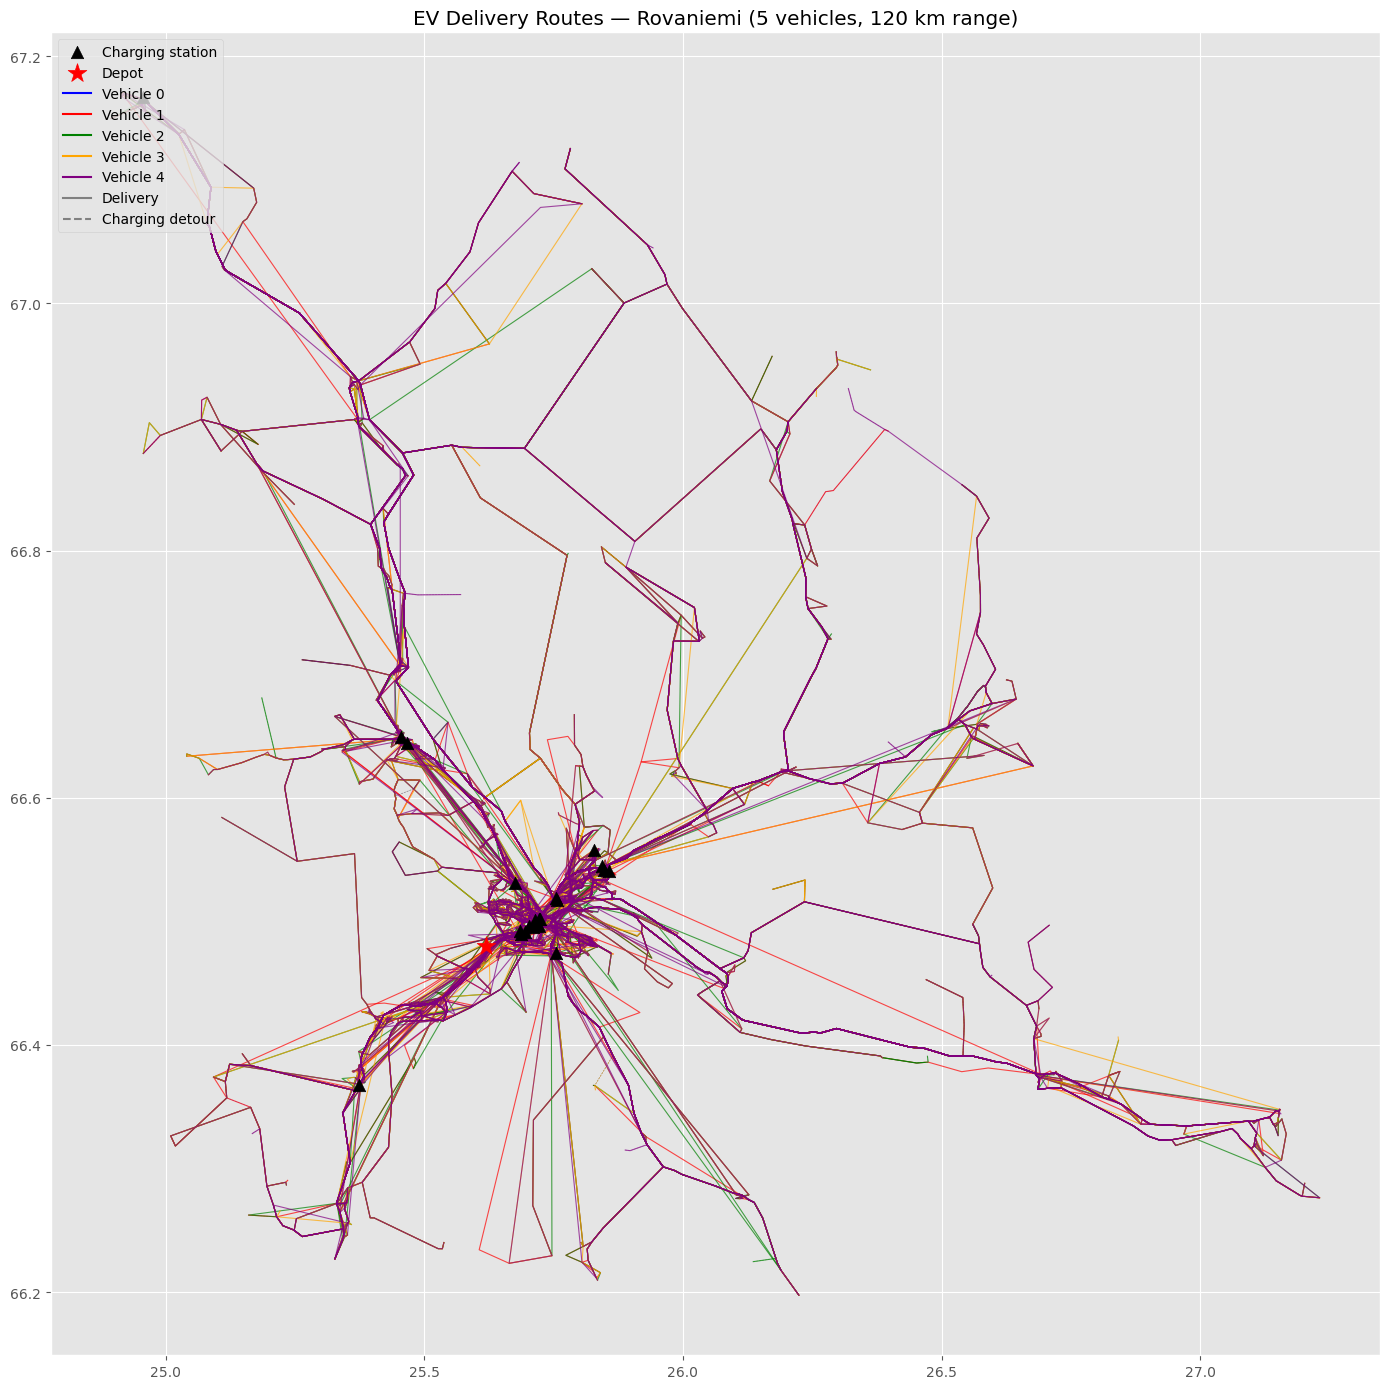


Charging stops per vehicle:
vehicle_id
1    188
2    197
3    192
4    190
Name: segment, dtype: int64

Total charging detours: 767
Total delivery segments: 772


In [14]:
# Save to file
routes_gdf.to_file("rovaniemi_routes.gpkg", driver="GPKG")
print("Saved to rovaniemi_routes.gpkg")

# Plot
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgba

colors = {0: 'blue', 1: 'red', 2: 'green', 3: 'orange', 4: 'purple'}
linestyles = {'delivery': '-', 'charging': '--'}

fig, ax = plt.subplots(figsize=(14, 14))

for _, row in routes_gdf.iterrows():
    if row['geometry'] is None:
        continue
    x, y = row['geometry'].xy
    ax.plot(
        x, y,
        color=colors[row['vehicle_id']],
        linestyle=linestyles[row['type']],
        linewidth=0.8 if row['type'] == 'delivery' else 0.4,
        alpha=0.7 if row['type'] == 'delivery' else 0.4
    )

# Charging stations
ax.scatter(
    charging_stations['longitude'],
    charging_stations['latitude'],
    c='black', s=80, zorder=5, marker='^', label='Charging station'
)

# Depot
ax.scatter(
    depot['longitude'].values[0],
    depot['latitude'].values[0],
    c='red', s=200, zorder=6, marker='*', label='Depot'
)

# Legend for vehicles
for vid, color in colors.items():
    ax.plot([], [], color=color, label=f'Vehicle {vid}')
ax.plot([], [], color='gray', linestyle='-', label='Delivery')
ax.plot([], [], color='gray', linestyle='--', label='Charging detour')

ax.set_title('EV Delivery Routes — Rovaniemi (5 vehicles, 120 km range)')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

# Summary stats
print("\nCharging stops per vehicle:")
print(routes_gdf[routes_gdf['type'] == 'charging'].groupby('vehicle_id')['segment'].count())
print(f"\nTotal charging detours: {len(routes_gdf[routes_gdf['type'] == 'charging'])}")
print(f"Total delivery segments: {len(routes_gdf[routes_gdf['type'] == 'delivery'])}")

In [15]:
AVG_SPEED_KMH = 40          # average urban/rural delivery speed
DELIVERY_TIME_MIN = 3        # minutes per building stop
CHARGING_TIME_MIN = 45       # typical fast charger stop

# Calculate time per segment
routes_gdf['distance_km'] = routes_gdf['distance_m'] / 1000
routes_gdf['drive_time_min'] = (routes_gdf['distance_km'] / AVG_SPEED_KMH) * 60

# Add delivery stop time only for delivery segments
routes_gdf['stop_time_min'] = routes_gdf.apply(
    lambda r: DELIVERY_TIME_MIN * buildings[buildings['vehicle_id'] == r['vehicle_id']].shape[0] / \
              routes_gdf[(routes_gdf['vehicle_id'] == r['vehicle_id']) & (routes_gdf['type'] == 'delivery')].shape[0]
    if r['type'] == 'delivery' else CHARGING_TIME_MIN,
    axis=1
)

routes_gdf['total_time_min'] = routes_gdf['drive_time_min'] + routes_gdf['stop_time_min']

# Summary per vehicle
summary = routes_gdf.groupby('vehicle_id').agg(
    total_distance_km=('distance_km', 'sum'),
    total_time_min=('total_time_min', 'sum'),
    charging_stops=('type', lambda x: (x == 'charging').sum())
).reset_index()

summary['total_time_hrs'] = (summary['total_time_min'] / 60).round(1)

print(summary)
print(f"\nAll vehicles working in parallel, total wall time: {summary['total_time_hrs'].max()} hrs")

   vehicle_id  total_distance_km  total_time_min  charging_stops  \
0           0          99.810974    10976.716461               0   
1           1       20375.322093    49849.983140             188   
2           2       21396.758802    51787.138204             197   
3           3       21044.261604    51033.392407             192   
4           4       20709.532098    50441.298146             190   

   total_time_hrs  
0           182.9  
1           830.8  
2           863.1  
3           850.6  
4           840.7  

All vehicles working in parallel, total wall time: 863.1 hrs


In [18]:
863/24

35.958333333333336

In [23]:
# Get the osm_nodes that vehicle 2 actually visited
vehicle2_routes = routes_gdf[routes_gdf['vehicle_id'] == 2]

# Buildings assigned to vehicle 2
v2_buildings = buildings[buildings['vehicle_id'] == 2].copy()

# Buildings where osm_node appears in the routing network
# We need to check which buildings were skipped during routing
# The simplest proxy: buildings far from any road node

# Check which nodes are actually reachable from depot
reachable_nodes = set(nx.single_source_dijkstra_path_length(
    G, depot_node, cutoff=120000, weight='length'
).keys())

v2_buildings['reachable'] = v2_buildings['osm_node'].isin(reachable_nodes)

reachable = v2_buildings[v2_buildings['reachable']]
unreachable = v2_buildings[~v2_buildings['reachable']]

print(f"Reachable: {len(reachable)}")
print(f"Unreachable: {len(unreachable)}")

Reachable: 3608
Unreachable: 1


In [ ]:
hours_per_day = 24
days = 7
available_hrs = hours_per_day * days  # 168 hrs

total_work_hrs = summary['total_time_hrs'].sum()
vehicles_needed = math.ceil(total_work_hrs / available_hrs)

print(f"Available hours per vehicle in 7 days (24h): {available_hrs} hrs")
print(f"Total work hours: {total_work_hrs:.1f} hrs")
print(f"Vehicles needed: {vehicles_needed}")

# How many more than current 5
print(f"Current fleet: 5 vehicles")
print(f"Additional vehicles needed: {max(0, vehicles_needed - 5)}")